# Time Series Classification Pipeline

**Pipeline for classifying CV_mCherry time series from two glucose conditions using machine learning**

This pipeline takes two experiment IDs (omids) as input and performs the complete classification workflow.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import sys
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

sys.path.insert(0, '/home/ianyang/stochastic_simulations/src')
from classifiers.lstm_classifier import lstm_classifier
from classifiers.transformer_classifier import transformer_classifier
%load_ext autoreload
%autoreload 2


In [2]:
DATA_DIR = Path('../transformed_exp_time_series_data')


def load_experiment_csvs(omid, data_dir=DATA_DIR):
    """Load pre-transformed steady-state CSVs for a given experiment omid."""
    files = sorted(glob.glob(str(data_dir / f'{omid}_*_mCherry_time_series.csv')))
    if not files:
        raise FileNotFoundError(f"No transformed CSV files found for omid '{omid}' in {data_dir}")
    exp_dict = {}
    for f in files:
        df = pd.read_csv(f)
        group_val = df['group'].iloc[0]
        exp_dict[f'group_{group_val}'] = df
    print(f"Loaded {len(exp_dict)} group(s) for {omid[:30]}...")
    return exp_dict


def plot_time_series_overview(time_series_dict, experiment_name, max_series=5):
    """Plot overview of time series data for each group."""
    fig, axes = plt.subplots(len(time_series_dict), 1, figsize=(15, 4 * len(time_series_dict)))
    if len(time_series_dict) == 1:
        axes = [axes]
    for idx, (group_name, df) in enumerate(time_series_dict.items()):
        ax = axes[idx]
        time_cols = [col for col in df.columns if col not in ['id', 'group', 'experiment']]
        time_values = [float(col) for col in time_cols]
        n_series = min(max_series, len(df))
        for i in range(n_series):
            cv_values = df.iloc[i][time_cols].values
            valid_mask = ~np.isnan(cv_values.astype(float))
            if valid_mask.any():
                ax.plot(
                    [time_values[j] for j in range(len(time_values)) if valid_mask[j]],
                    cv_values[valid_mask], alpha=0.7, label=f'ID {df.iloc[i]["id"]}'
                )
        ax.set_title(f'{experiment_name} - {group_name} ({len(df)} series)')
        ax.set_xlabel('Time (hours)')
        ax.set_ylabel('CV_mCherry')
        ax.grid(True, alpha=0.3)
        if n_series <= 10:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


def balance_dataset_dimensions(exp1_dict, exp2_dict):
    """Balance number of series and timepoints across experiments."""
    min_series = min(
        min(df.shape[0] for df in exp1_dict.values()),
        min(df.shape[0] for df in exp2_dict.values()),
    )
    exp1_balanced = {k: df.iloc[:min_series] for k, df in exp1_dict.items()}
    exp2_balanced = {k: df.iloc[:min_series] for k, df in exp2_dict.items()}

    def _min_timepoints(exp_dict):
        return min(
            len([c for c in df.columns if c not in ['id', 'group', 'experiment']])
            for df in exp_dict.values()
        )

    min_tp = min(_min_timepoints(exp1_balanced), _min_timepoints(exp2_balanced))

    def _truncate(exp_dict, n):
        meta = ['id', 'group', 'experiment']
        return {
            k: df[meta + sorted([c for c in df.columns if c not in meta],
                                key=float)[:n]].copy()
            for k, df in exp_dict.items()
        }

    print(f"Balanced to: {min_series} series per group, {min_tp} timepoints")
    return _truncate(exp1_balanced, min_tp), _truncate(exp2_balanced, min_tp)


def create_ml_dataset(exp1_dict, exp2_dict):
    """Create final ML dataset with labels (0=exp1, 1=exp2)."""
    X_list, y_list = [], []
    for label, exp_dict in [(0, exp1_dict), (1, exp2_dict)]:
        for df in exp_dict.values():
            time_cols = [c for c in df.columns if c not in ['id', 'group', 'experiment']]
            for _, row in df.iterrows():
                vals = row[time_cols].values.astype(float)
                if np.sum(~np.isnan(vals)) / len(vals) >= 0.5:
                    X_list.append(vals)
                    y_list.append(label)
    return np.stack(X_list), np.array(y_list, dtype=int)


In [3]:
def run_classification_pipeline(omid1, omid2):
    """
    Classify CV_mCherry time series from two experiments.

    Loads pre-transformed steady-state CSVs from transformed_exp_time_series_data/
    instead of rerunning the slow preprocessing pipeline.

    Parameters
    ----------
    omid1 : str  First experiment ID (label 0)
    omid2 : str  Second experiment ID (label 1)

    Returns
    -------
    dict with keys: results_df, X, y, results, best_model, best_accuracy
    """
    # 1. Load pre-transformed CSVs
    exp1 = load_experiment_csvs(omid1)
    exp2 = load_experiment_csvs(omid2)

    for exp_name, exp_dict in [('Exp1', exp1), ('Exp2', exp2)]:
        for group_name, df in exp_dict.items():
            time_cols = [c for c in df.columns if c not in ['id', 'group', 'experiment']]
            print(f"  {exp_name} {group_name}: {df.shape[0]} series x {len(time_cols)} timepoints")

    # 2. Visualise steady-state time series
    plot_time_series_overview(exp1, f'Exp1 - {omid1[:25]}...', max_series=3)
    plot_time_series_overview(exp2, f'Exp2 - {omid2[:25]}...', max_series=3)

    # 3. Balance and create ML dataset
    exp1_balanced, exp2_balanced = balance_dataset_dimensions(exp1, exp2)
    X, y = create_ml_dataset(exp1_balanced, exp2_balanced)

    print(f"Final dataset: {X.shape[0]} samples x {X.shape[1]} timepoints")
    print(f"Label distribution: {np.bincount(y)} (0={omid1[:30]}..., 1={omid2[:30]}...)")

    # 4. Visualise class differences
    class_0_means = [np.nanmean(X[i]) for i in range(len(X)) if y[i] == 0]
    class_1_means = [np.nanmean(X[i]) for i in range(len(X)) if y[i] == 1]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    for i in np.where(y == 0)[0][:5]:
        axes[0].plot(X[i], alpha=0.7, color='blue',
                     label='Experiment 1' if i == np.where(y == 0)[0][0] else '')
    for i in np.where(y == 1)[0][:5]:
        axes[0].plot(X[i], alpha=0.7, color='red',
                     label='Experiment 2' if i == np.where(y == 1)[0][0] else '')
    axes[0].set_title('Sample Time Series by Class')
    axes[0].set_xlabel('Time Points')
    axes[0].set_ylabel('CV_mCherry')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].hist(class_0_means, alpha=0.7, label='Experiment 1', bins=20, color='blue')
    axes[1].hist(class_1_means, alpha=0.7, label='Experiment 2', bins=20, color='red')
    axes[1].set_title('Distribution of Mean Values')
    axes[1].set_xlabel('CV_mCherry')
    axes[1].set_ylabel('Frequency')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Experiment 1 mean: {np.mean(class_0_means):.3f} +/- {np.std(class_0_means):.3f}")
    print(f"Experiment 2 mean: {np.mean(class_1_means):.3f} +/- {np.std(class_1_means):.3f}")

    # 5. ML classification
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
    print(f"Train: {np.bincount(y_train)}, Test: {np.bincount(y_test)}")

    svm_model = SVC(C=1.0, gamma='scale', kernel='rbf', random_state=42)
    svm_model.fit(X_train, y_train)
    svm_accuracy = accuracy_score(y_test, svm_model.predict(X_test))
    print(f"SVM Accuracy: {svm_accuracy:.4f}")
    print(classification_report(y_test, svm_model.predict(X_test), target_names=['Exp1', 'Exp2']))

    lstm_accuracy = lstm_classifier(
        X_train, X_val, X_test, y_train, y_val, y_test,
        epochs=100, hidden_size=128, num_layers=4, dropout_rate=0.2,
        learning_rate=0.001, batch_size=64,
        use_conv1d=True, use_attention=True, num_attention_heads=4, use_auxiliary=True,
    )

    transformer_accuracy = transformer_classifier(
        X_train, X_val, X_test, y_train, y_val, y_test,
        d_model=128, nhead=8, num_layers=4, epochs=50,
        use_conv1d=True, use_auxiliary=True,
    )

    # 6. Results
    results = {'SVM': svm_accuracy, 'LSTM': lstm_accuracy, 'Transformer': transformer_accuracy}

    bars = plt.bar(results.keys(), results.values(),
                   color=['skyblue', 'lightcoral', 'lightgreen'], alpha=0.8, edgecolor='black')
    plt.ylabel('Test Accuracy')
    plt.title('Model Performance Comparison')
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    for bar, acc in zip(bars, results.values()):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.show()

    best_model = max(results, key=results.get)
    best_accuracy = results[best_model]
    print(f"Best: {best_model} ({best_accuracy:.4f})")

    results_df = pd.DataFrame([{
        'Experiment_1': omid1, 'Experiment_2': omid2,
        'Total_Series': X.shape[0], 'Timepoints': X.shape[1],
        'SVM_Accuracy': svm_accuracy, 'LSTM_Accuracy': lstm_accuracy,
        'Transformer_Accuracy': transformer_accuracy,
        'Best_Model': best_model, 'Best_Accuracy': best_accuracy,
    }])

    return {
        'results_df': results_df, 'X': X, 'y': y,
        'results': results, 'best_model': best_model, 'best_accuracy': best_accuracy,
    }


## Run Pipeline

Execute the complete pipeline with two experiment IDs

Loaded 3 group(s) for 19316_2020_10_26_steadystate_g...
Loaded 3 group(s) for 20213_2021_09_07_steady_0p01gl...
  Exp1 group_1344_6: 71 series x 94 timepoints
  Exp1 group_1346_4: 84 series x 128 timepoints
  Exp1 group_1347: 78 series x 126 timepoints
  Exp2 group_1344: 241 series x 146 timepoints
  Exp2 group_1346: 231 series x 105 timepoints
  Exp2 group_1347: 275 series x 89 timepoints


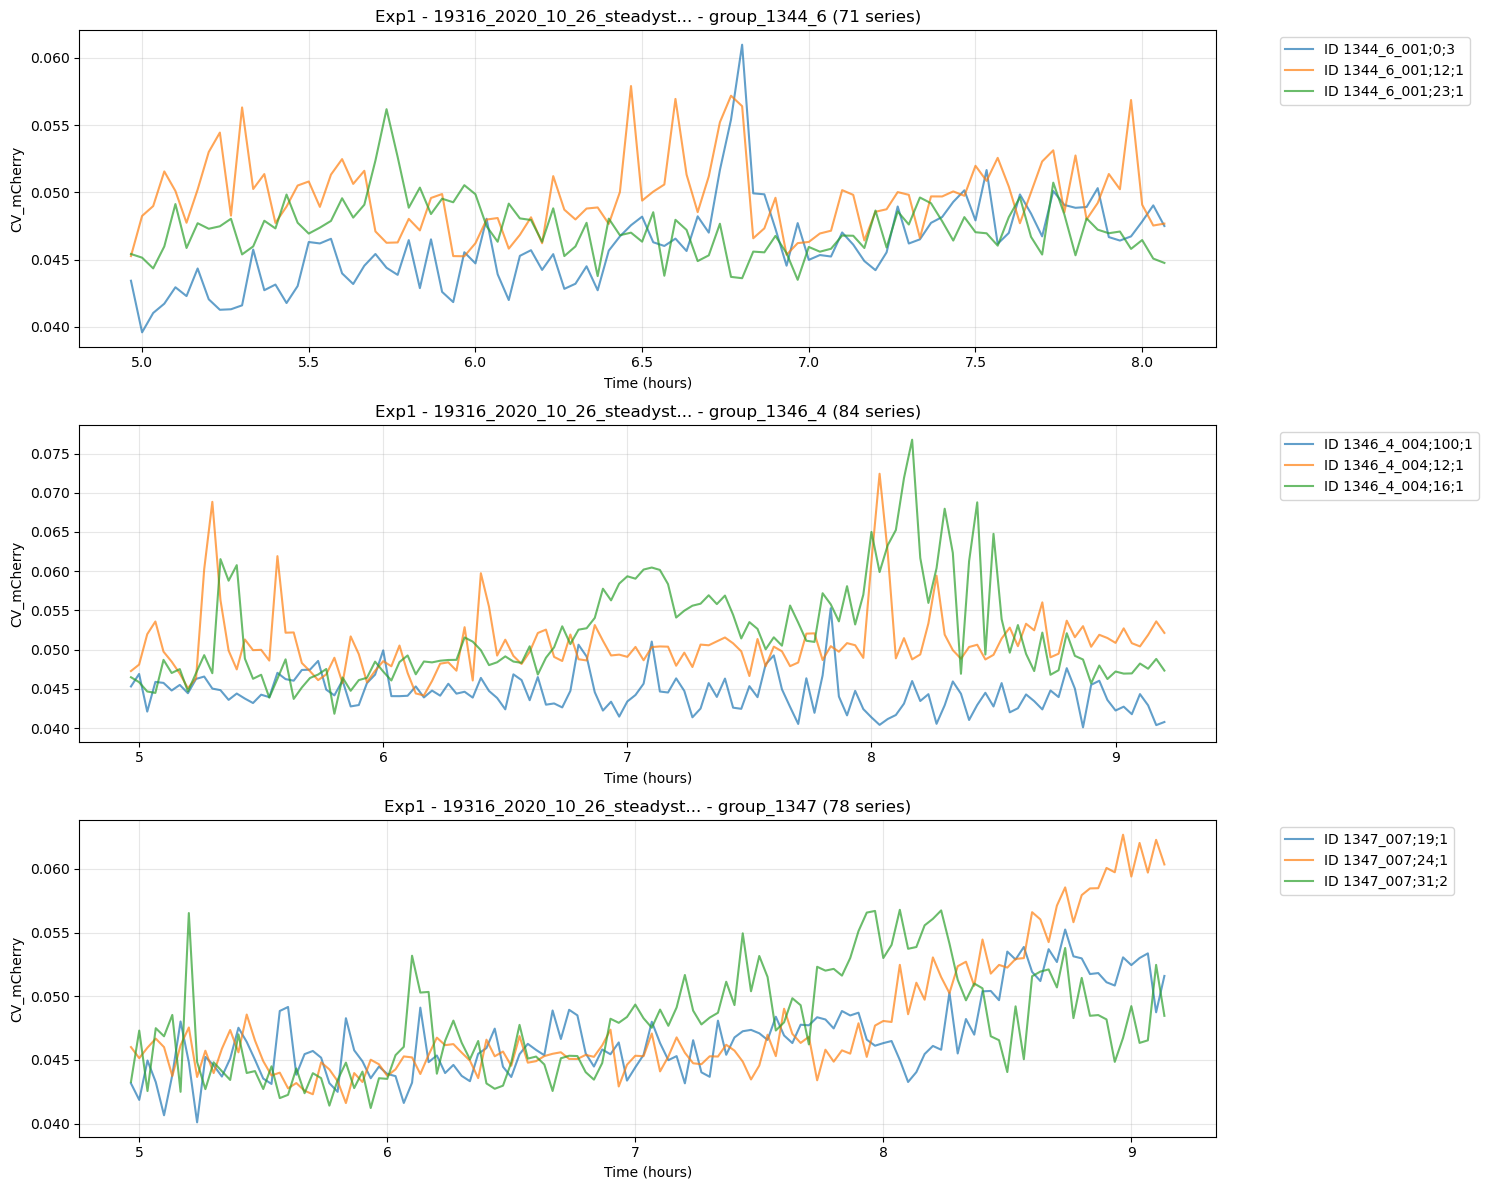

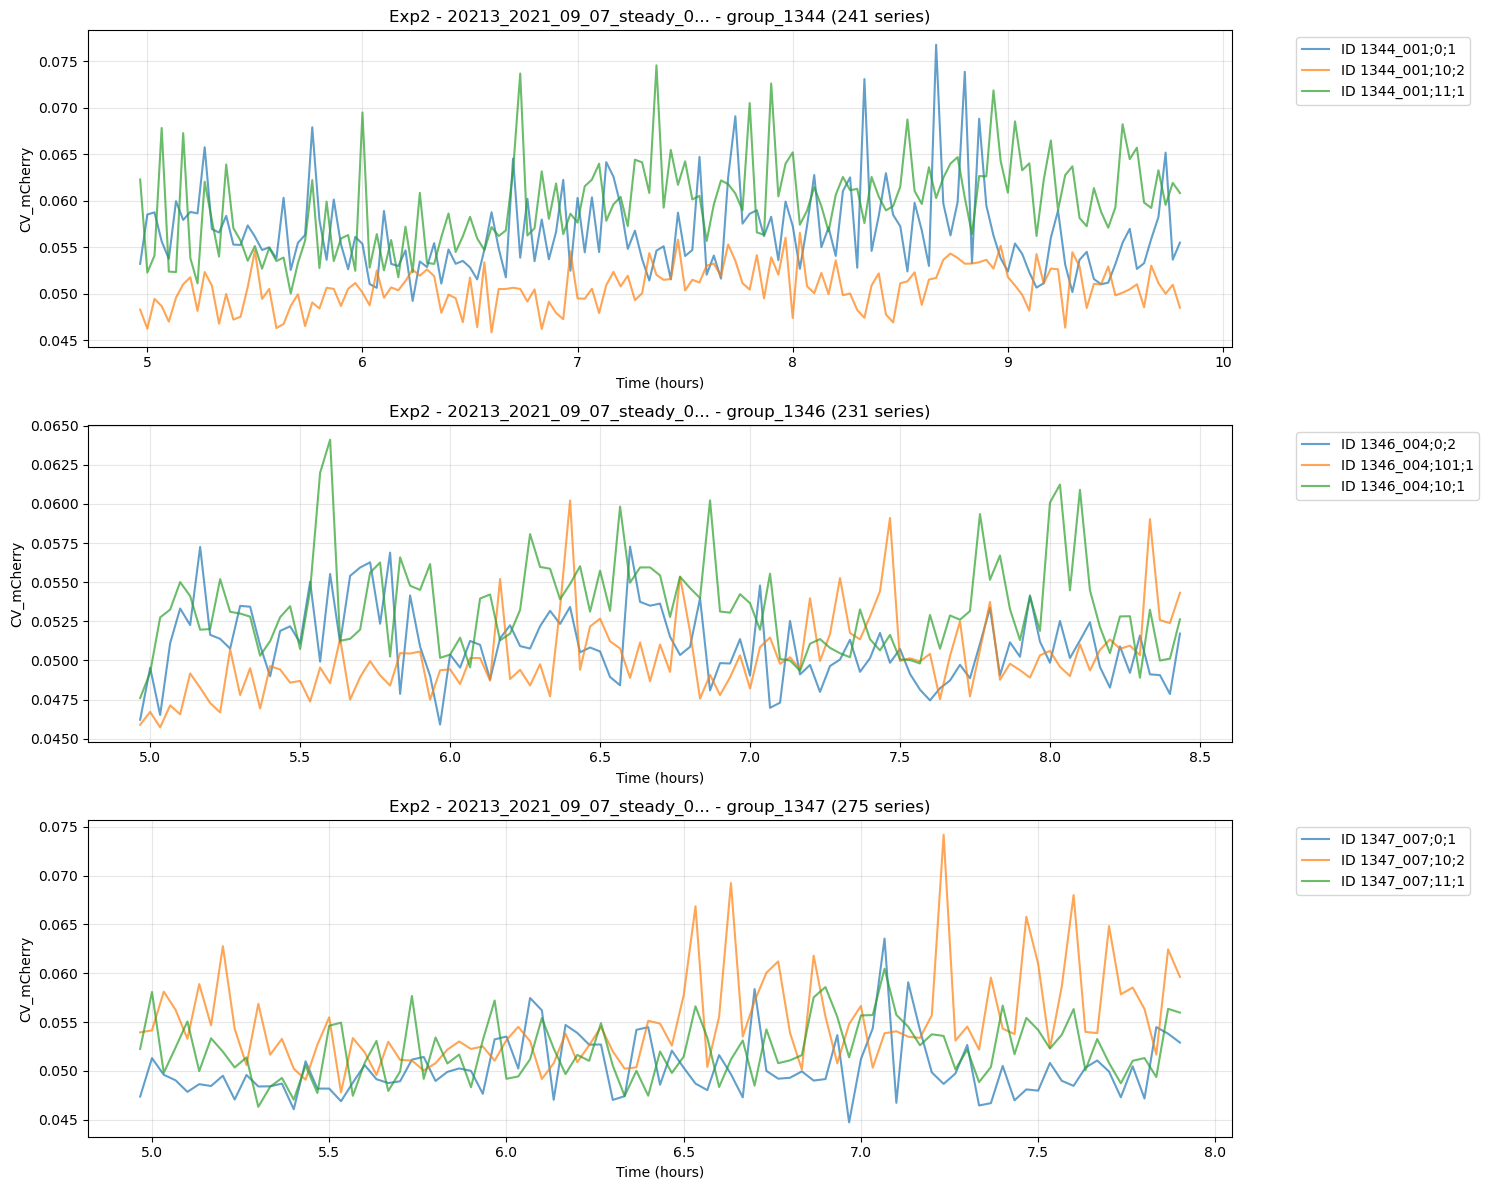

Balanced to: 71 series per group, 89 timepoints
Final dataset: 426 samples x 89 timepoints
Label distribution: [213 213] (0=19316_2020_10_26_steadystate_g..., 1=20213_2021_09_07_steady_0p01gl...)


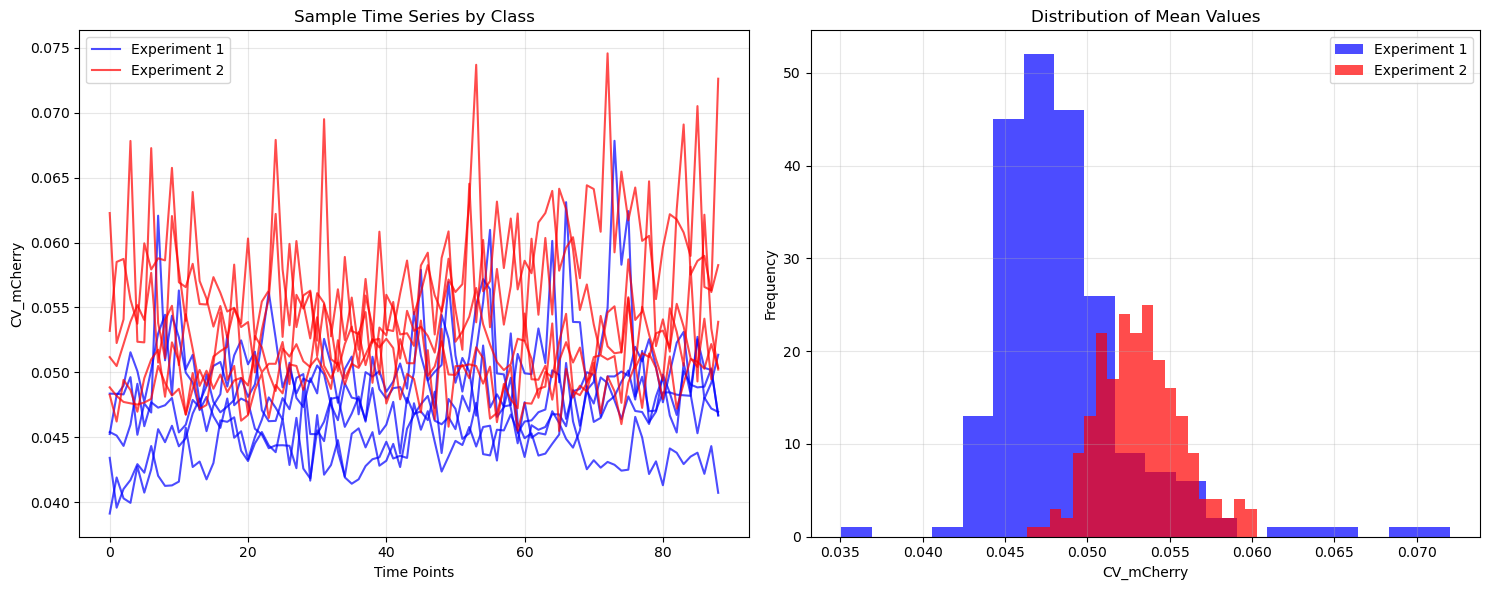

Experiment 1 mean: 0.049 +/- 0.004
Experiment 2 mean: 0.053 +/- 0.003
Train: [127 128], Test: [43 43]
SVM Accuracy: 0.8488
              precision    recall  f1-score   support

        Exp1       0.83      0.88      0.85        43
        Exp2       0.88      0.81      0.84        43

    accuracy                           0.85        86
   macro avg       0.85      0.85      0.85        86
weighted avg       0.85      0.85      0.85        86

=== LSTM with Conv1D and 4-Head Attention Accuracy: 0.87 ===
Starting training...
Epoch [1/50] | train_loss 2.5323 | train_acc 0.4784 | val_loss 1.4002 | val_acc 0.5059
No improvement (1/10).
Epoch [2/50] | train_loss 1.1933 | train_acc 0.5020 | val_loss 0.7718 | val_acc 0.4941
Epoch [3/50] | train_loss 0.7020 | train_acc 0.4941 | val_loss 0.6247 | val_acc 0.6706
Epoch [4/50] | train_loss 0.6032 | train_acc 0.6627 | val_loss 0.5638 | val_acc 0.8118
No improvement (1/10).
Epoch [5/50] | train_loss 0.5472 | train_acc 0.7412 | val_loss 0.4958 | va

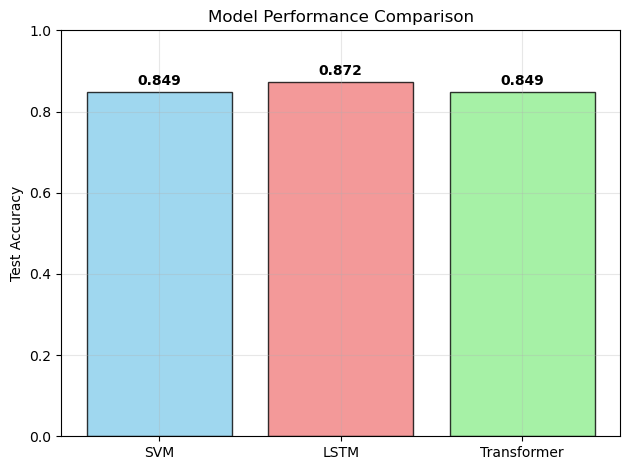

Best: LSTM (0.8721)


In [4]:
# Run the complete pipeline with the original experiment IDs
omid1 = '19316_2020_10_26_steadystate_glucose_144m_2w2_00'  # Experiment 1 (label 0)
omid2 = '20213_2021_09_07_steady_0p01glc_1344_1346_1347_00'  # Experiment 2 (label 1)

pipeline_results = run_classification_pipeline(omid1, omid2)

In [5]:
# Access results
results_df = pipeline_results['results_df']
print("Results DataFrame:")
print(results_df)

Results DataFrame:
                                       Experiment_1  \
0  19316_2020_10_26_steadystate_glucose_144m_2w2_00   

                                        Experiment_2  Total_Series  \
0  20213_2021_09_07_steady_0p01glc_1344_1346_1347_00           426   

   Timepoints  SVM_Accuracy  LSTM_Accuracy  Transformer_Accuracy Best_Model  \
0          89      0.848837       0.872093              0.848837       LSTM   

   Best_Accuracy  
0       0.872093  


Loaded 3 group(s) for 19554_2020_12_06_steadystate_g...
Loaded 3 group(s) for 19566_2020_12_07_steadystate_g...
  Exp1 group_756: 196 series x 128 timepoints
  Exp1 group_900: 193 series x 153 timepoints
  Exp1 group_903: 170 series x 150 timepoints
  Exp2 group_1344: 214 series x 156 timepoints
  Exp2 group_1346: 231 series x 135 timepoints
  Exp2 group_1347: 200 series x 117 timepoints


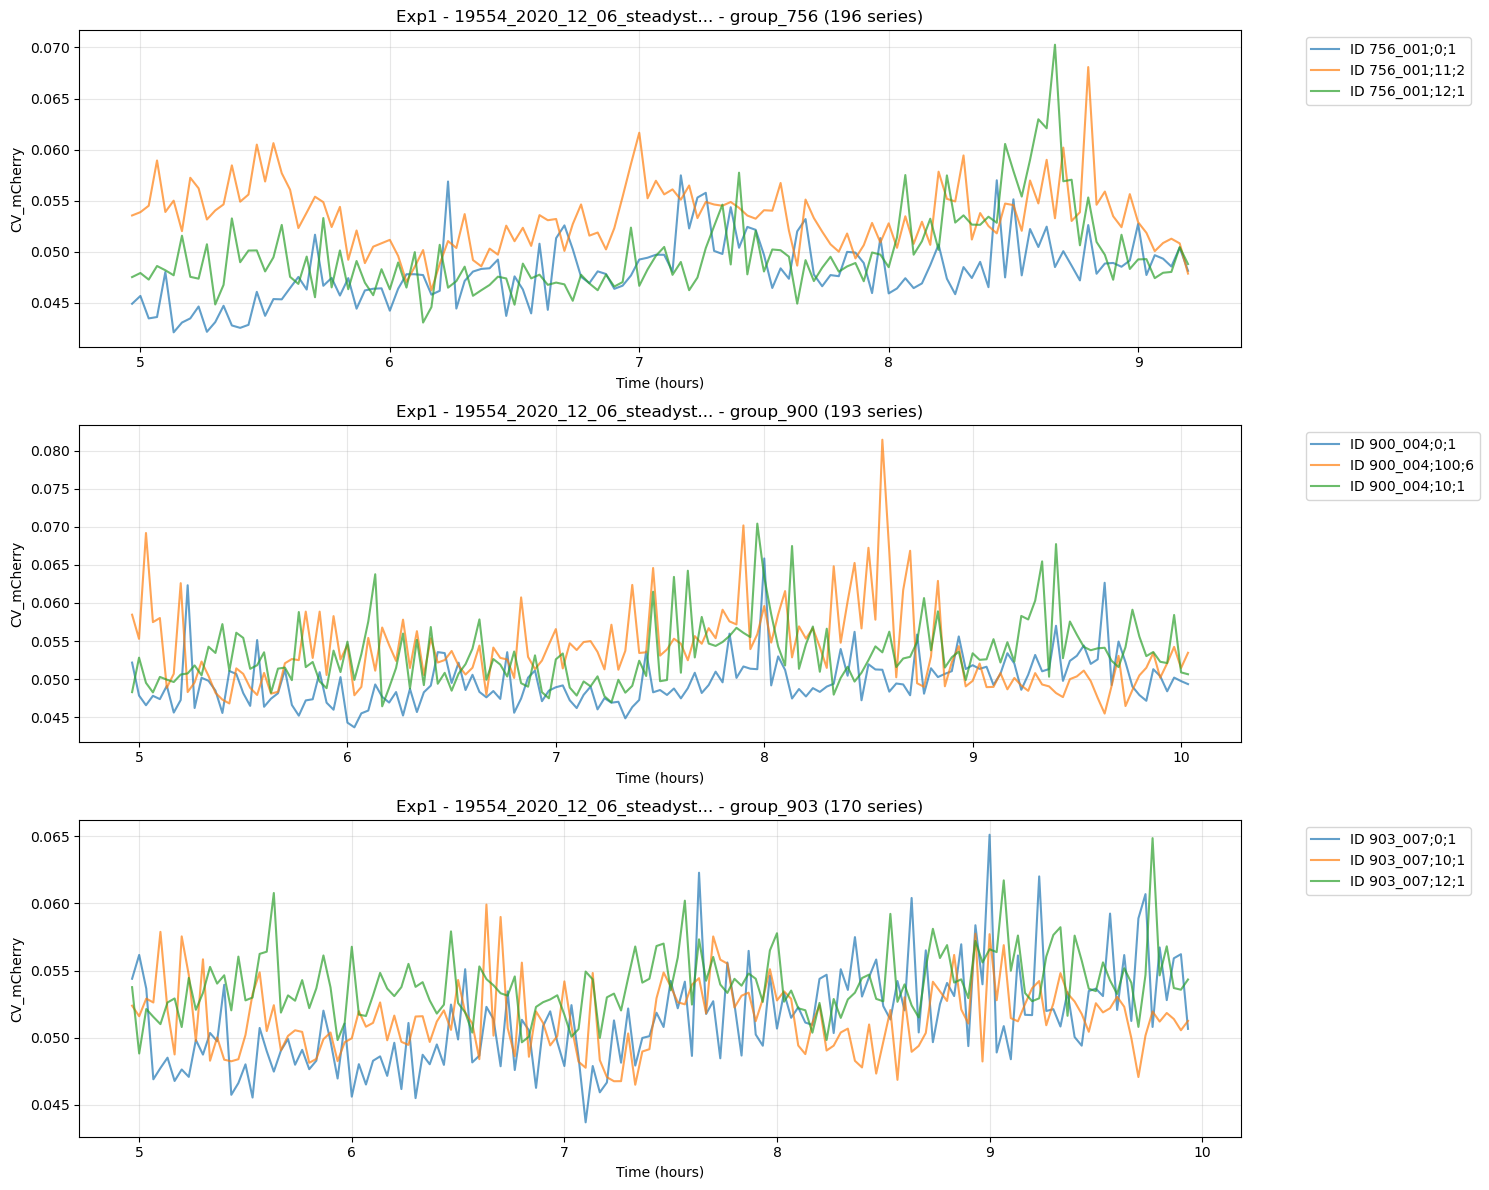

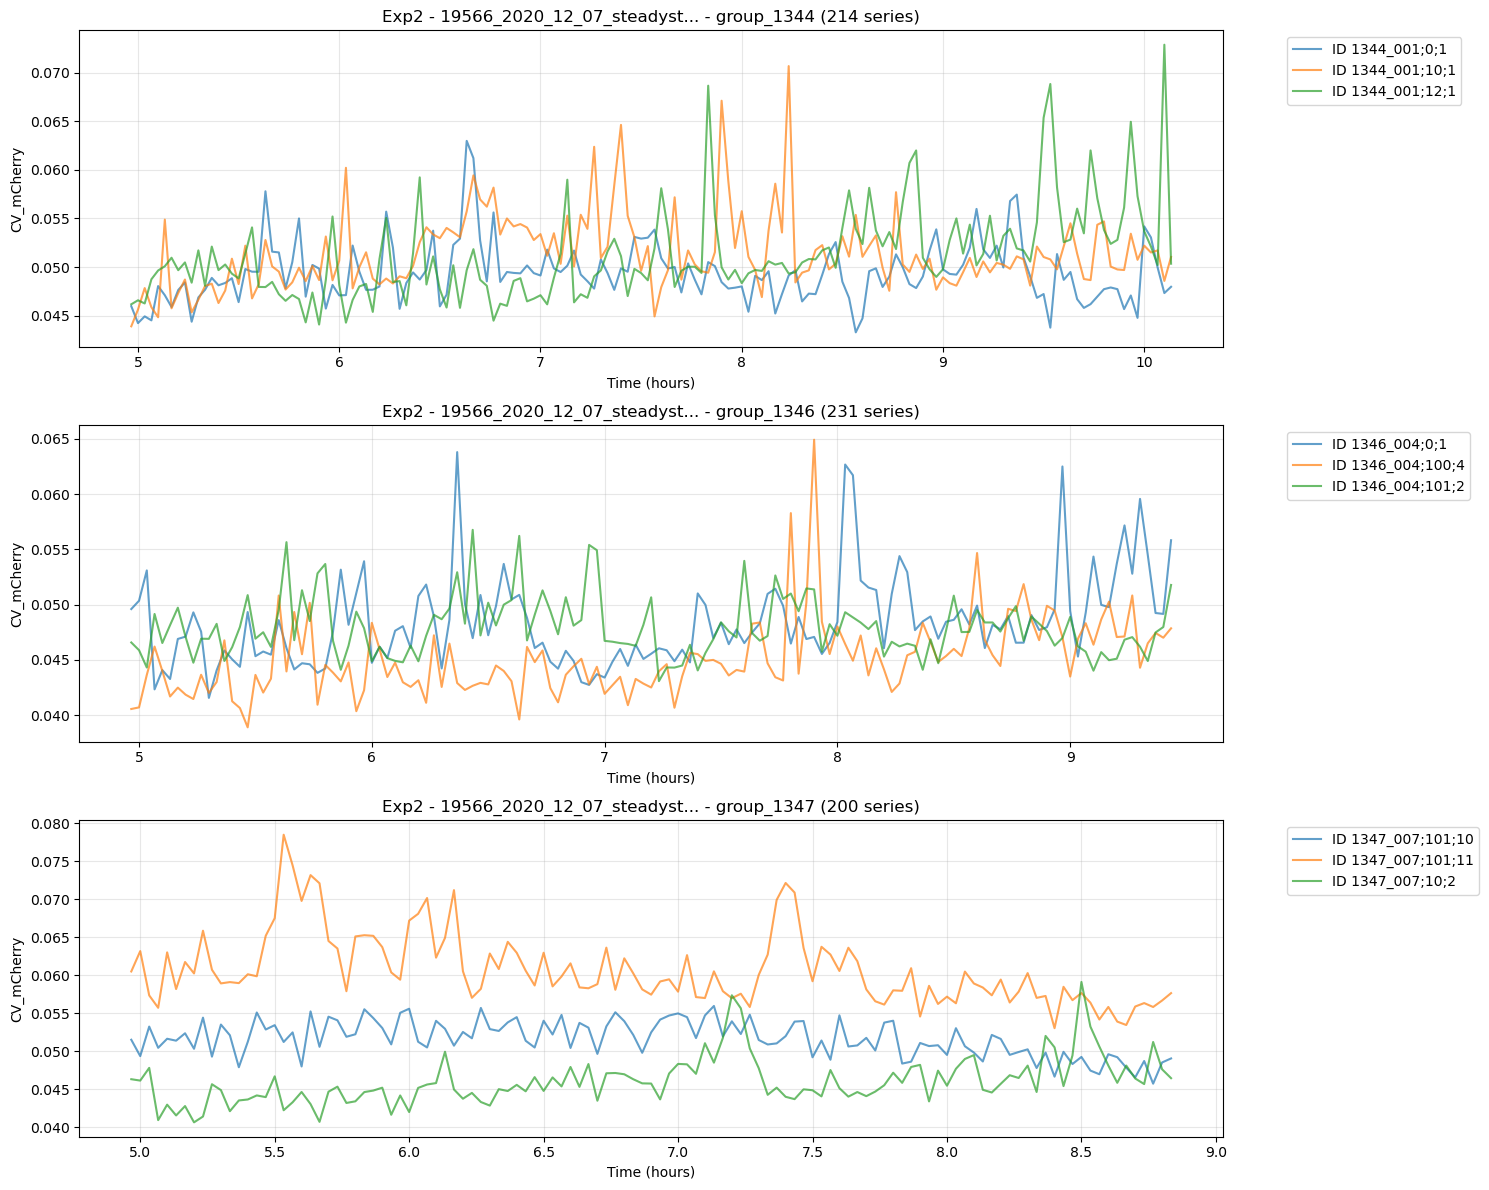

Balanced to: 170 series per group, 117 timepoints
Final dataset: 1020 samples x 117 timepoints
Label distribution: [510 510] (0=19554_2020_12_06_steadystate_g..., 1=19566_2020_12_07_steadystate_g...)


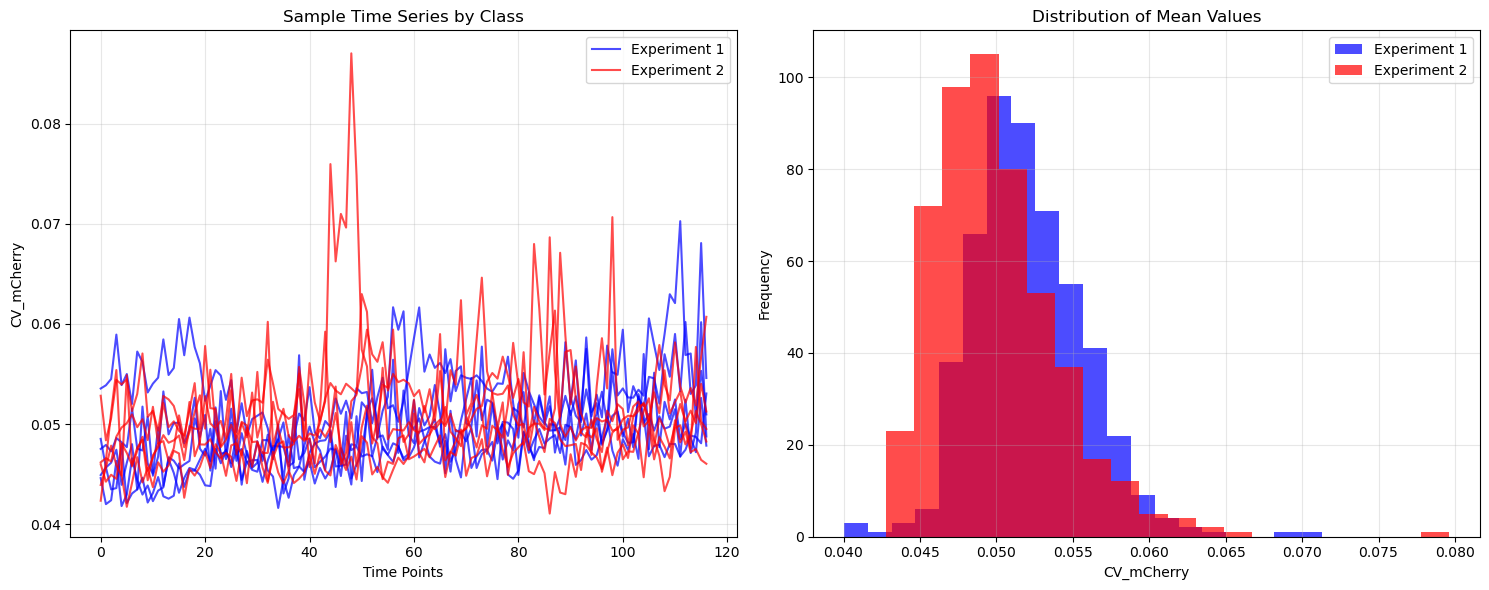

Experiment 1 mean: 0.052 +/- 0.004
Experiment 2 mean: 0.050 +/- 0.004
Train: [306 306], Test: [102 102]
SVM Accuracy: 0.7549
              precision    recall  f1-score   support

        Exp1       0.75      0.77      0.76       102
        Exp2       0.77      0.74      0.75       102

    accuracy                           0.75       204
   macro avg       0.76      0.75      0.75       204
weighted avg       0.76      0.75      0.75       204

=== LSTM with Conv1D and 4-Head Attention Accuracy: 0.74 ===
Starting training...
Epoch [1/50] | train_loss 1.7968 | train_acc 0.5131 | val_loss 1.0010 | val_acc 0.5000
No improvement (1/10).
Epoch [2/50] | train_loss 0.7926 | train_acc 0.5180 | val_loss 0.6835 | val_acc 0.5000
No improvement (2/10).
Epoch [3/50] | train_loss 0.6890 | train_acc 0.5621 | val_loss 0.7226 | val_acc 0.5000
Epoch [4/50] | train_loss 0.6573 | train_acc 0.6225 | val_loss 0.7702 | val_acc 0.5049
Epoch [5/50] | train_loss 0.6476 | train_acc 0.6487 | val_loss 0.6299 | 

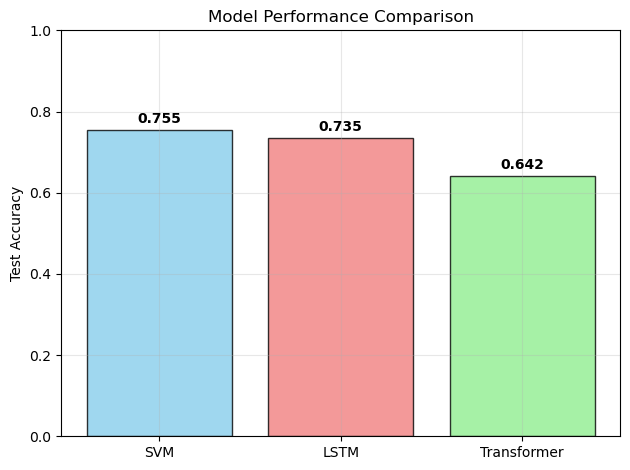

Best: SVM (0.7549)
Results DataFrame:
                                        Experiment_1  \
0  19554_2020_12_06_steadystate_glucose_2w0p01_90...   

                                        Experiment_2  Total_Series  \
0  19566_2020_12_07_steadystate_glucose_1344m_2w0...          1020   

   Timepoints  SVM_Accuracy  LSTM_Accuracy  Transformer_Accuracy Best_Model  \
0         117      0.754902       0.735294              0.642157        SVM   

   Best_Accuracy  
0       0.754902  


In [6]:
# Run the complete pipeline with the original experiment IDs
omid3 = '19554_2020_12_06_steadystate_glucose_2w0p01_900m_00'  # Experiment 3 (label 0)
omid4 = '19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01'  # Experiment 4 (label 1)

pipeline_results = run_classification_pipeline(omid3, omid4)

# Access results
results_df = pipeline_results['results_df']
print("Results DataFrame:")
print(results_df)

Loaded 3 group(s) for 19316_2020_10_26_steadystate_g...
Loaded 3 group(s) for 19566_2020_12_07_steadystate_g...
  Exp1 group_1344_6: 71 series x 94 timepoints
  Exp1 group_1346_4: 84 series x 128 timepoints
  Exp1 group_1347: 78 series x 126 timepoints
  Exp2 group_1344: 214 series x 156 timepoints
  Exp2 group_1346: 231 series x 135 timepoints
  Exp2 group_1347: 200 series x 117 timepoints


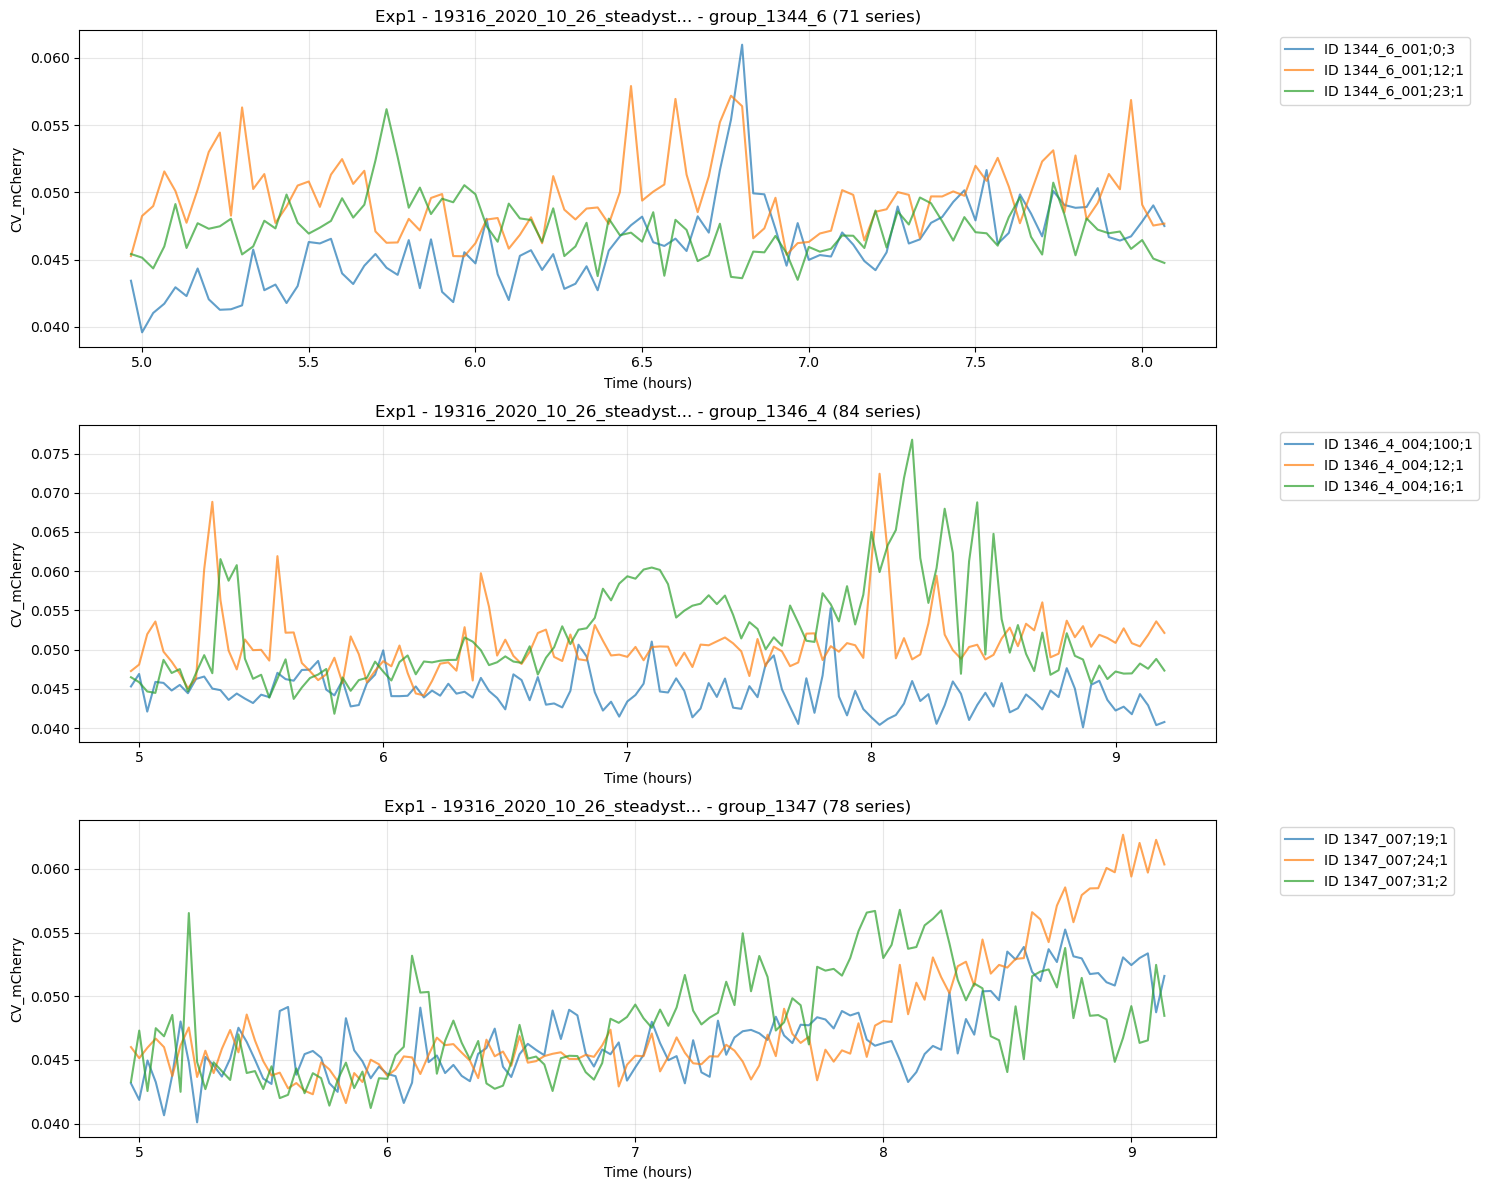

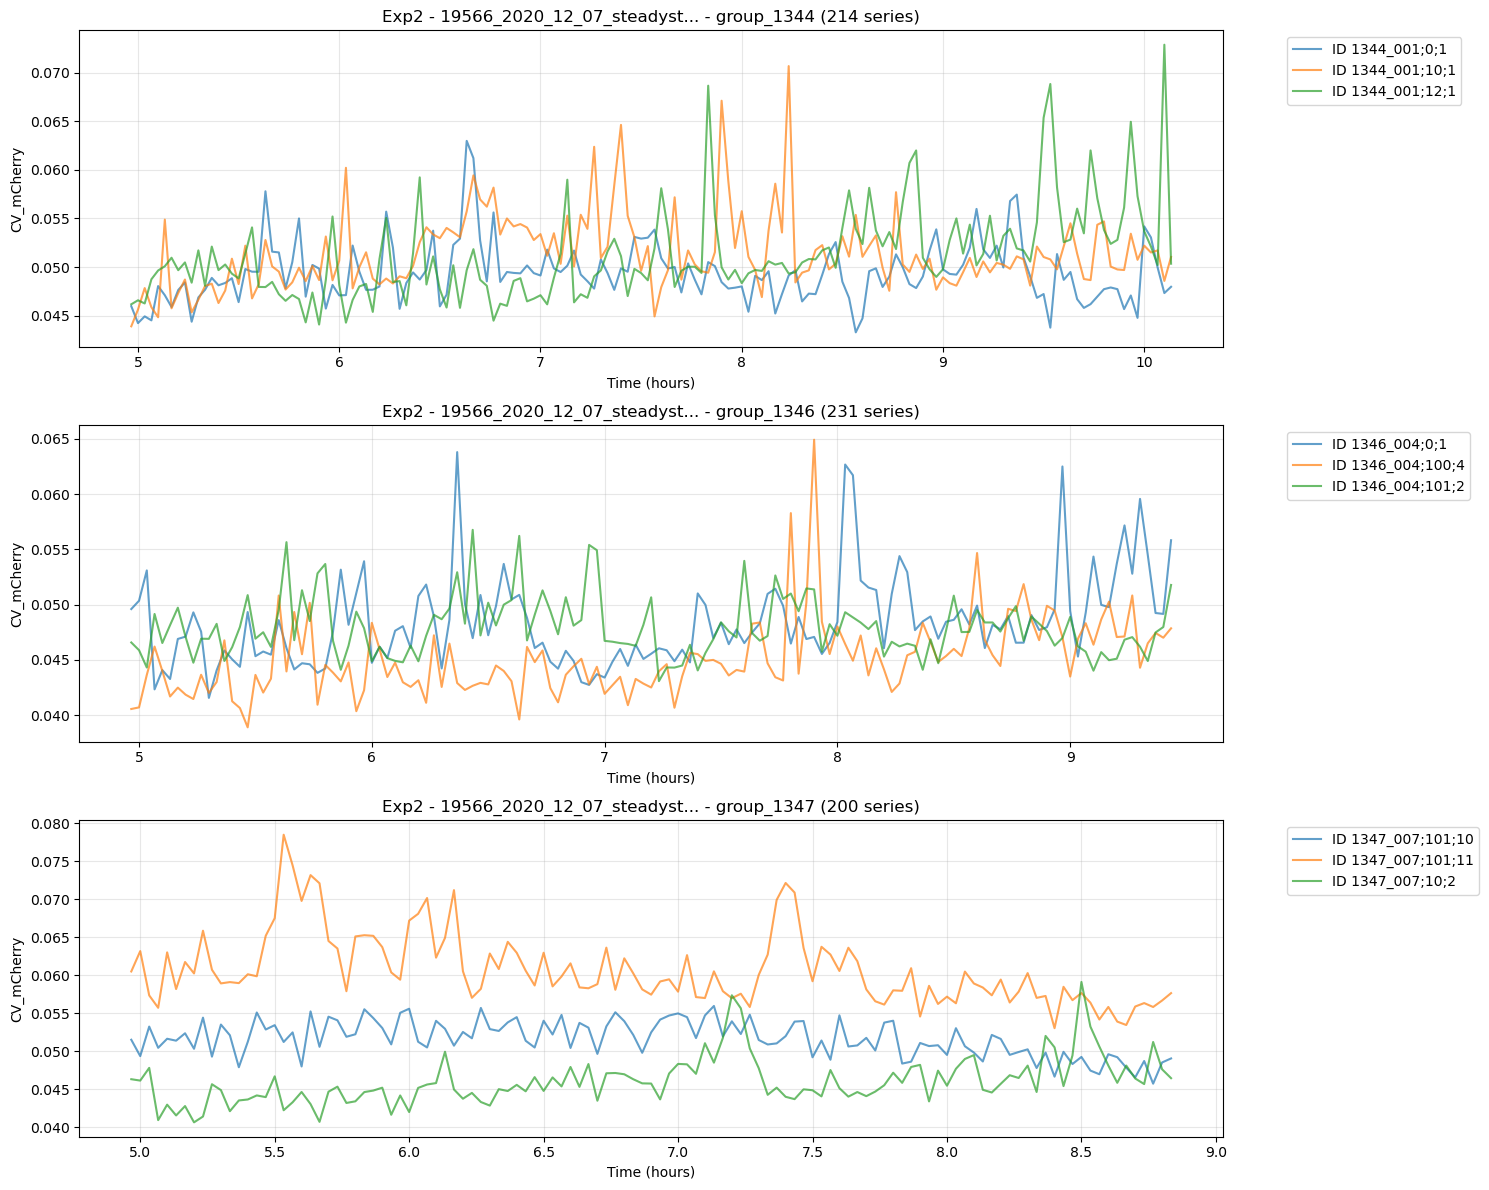

Balanced to: 71 series per group, 94 timepoints
Final dataset: 426 samples x 94 timepoints
Label distribution: [213 213] (0=19316_2020_10_26_steadystate_g..., 1=19566_2020_12_07_steadystate_g...)


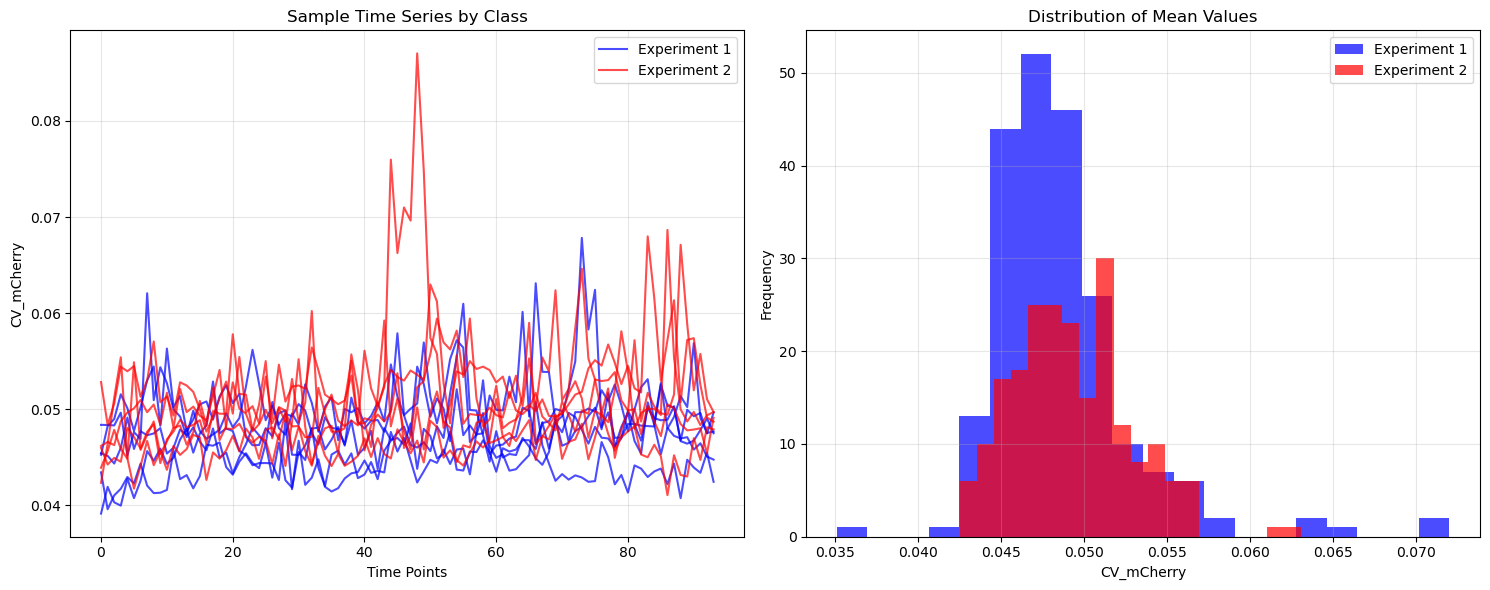

Experiment 1 mean: 0.049 +/- 0.004
Experiment 2 mean: 0.049 +/- 0.004
Train: [127 128], Test: [43 43]
SVM Accuracy: 0.6628
              precision    recall  f1-score   support

        Exp1       0.65      0.70      0.67        43
        Exp2       0.68      0.63      0.65        43

    accuracy                           0.66        86
   macro avg       0.66      0.66      0.66        86
weighted avg       0.66      0.66      0.66        86

=== LSTM with Conv1D and 4-Head Attention Accuracy: 0.56 ===
Starting training...
Epoch [1/50] | train_loss 2.5538 | train_acc 0.4784 | val_loss 1.4204 | val_acc 0.5059
No improvement (1/10).
Epoch [2/50] | train_loss 1.2515 | train_acc 0.4941 | val_loss 1.1994 | val_acc 0.4941
No improvement (2/10).
Epoch [3/50] | train_loss 1.1102 | train_acc 0.5020 | val_loss 0.7325 | val_acc 0.5059
No improvement (3/10).
Epoch [4/50] | train_loss 0.7735 | train_acc 0.4980 | val_loss 0.7345 | val_acc 0.4941
No improvement (4/10).
Epoch [5/50] | train_loss 0.

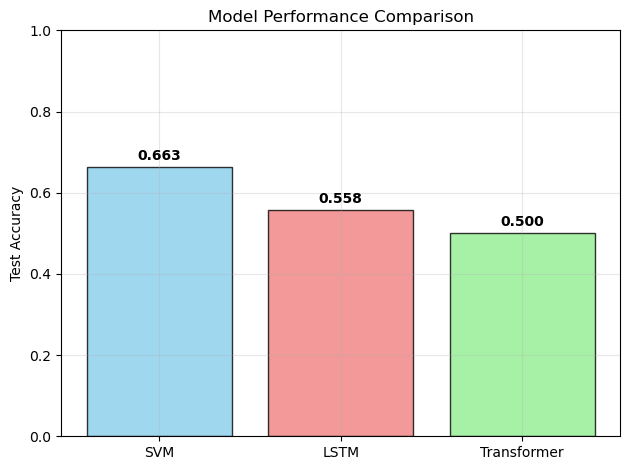

Best: SVM (0.6628)
Results DataFrame:
                                       Experiment_1  \
0  19316_2020_10_26_steadystate_glucose_144m_2w2_00   

                                        Experiment_2  Total_Series  \
0  19566_2020_12_07_steadystate_glucose_1344m_2w0...           426   

   Timepoints  SVM_Accuracy  LSTM_Accuracy  Transformer_Accuracy Best_Model  \
0          94      0.662791        0.55814                   0.5        SVM   

   Best_Accuracy  
0       0.662791  


In [7]:
# Run the complete pipeline with the original experiment IDs
pipeline_results = run_classification_pipeline(omid1, omid4)

# Access results
results_df = pipeline_results['results_df']
print("Results DataFrame:")
print(results_df)